# Disaster Tweets 재난 트윗 분류

트윗이 실제 재난(1)인지 아닌지 분류. 평가지표 F1.

1. EDA
2. Baseline: TF-IDF + LogReg / LinearSVM
3. 엔티티 피처 실험
4. DistilBERT
5. 분석 (F1, Confusion Matrix, FP/FN)
6. 제출

In [1]:
# import 한 번에
import os, re, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore") # 잔소리 끔
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

SEED = 42
def seed_everything(seed=SEED):
 random.seed(seed); np.random.seed(seed)
 try:
 import torch
 torch.manual_seed(seed)
 if torch.backends.mps.is_available(): torch.mps.manual_seed(seed)
 except Exception:
 pass
seed_everything()

DATA_DIR = "data"
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
print("setup done. seed =", SEED)

setup done. seed = 42


## 0. 데이터 로드 & EDA

In [2]:
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
print("train:", train.shape, "| test:", test.shape)
print("\ncolumns:", list(train.columns))
train.head()

train: (7613, 5) | test: (3263, 4)

columns: ['id', 'keyword', 'location', 'text', 'target']


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


In [3]:
# 결측 확인. location 많이 빌 듯
print("=== 결측치 (train) ===")
print(train.isna().sum())
print("\n=== 결측치 (test) ===")
print(test.isna().sum())
# location 1/3쯤 빔, keyword는 거의 다 있음. text는 안 빔(이게 핵심)

=== 결측치 (train) ===
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

=== 결측치 (test) ===
id             0
keyword       26
location    1105
text           0
dtype: int64


target
0    4342
1    3271
Name: count, dtype: int64 
양성(1) 비율: 0.4297


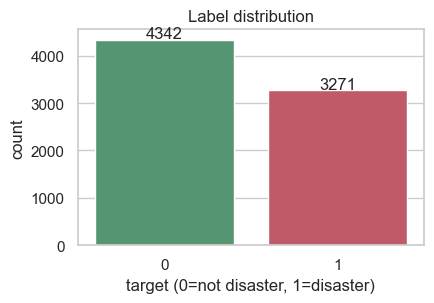

In [4]:
# 라벨 분포
counts = train["target"].value_counts().sort_index()
print(counts, "\n양성(1) 비율:", round(train["target"].mean(), 4))

fig, ax = plt.subplots(figsize=(4.5, 3.2))
sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, palette=["#4C9F70", "#D1495B"])
ax.set_xlabel("target (0=not disaster, 1=disaster)"); ax.set_ylabel("count")
ax.set_title("Label distribution")
for i, v in enumerate(counts.values): ax.text(i, v+30, str(v), ha="center")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/label_dist.png", dpi=120); plt.show()
# 43/57. 심한 불균형 아님. 그냥 F1로 감

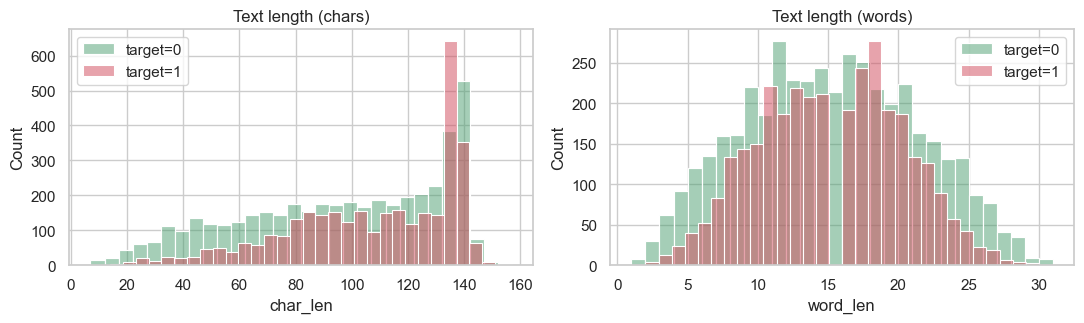

        char_len  word_len
target                    
0           95.7      14.7
1          108.1      15.2


In [5]:
# 길이로 갈리나?
train["char_len"] = train["text"].str.len()
train["word_len"] = train["text"].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, col, title in zip(axes, ["char_len", "word_len"], ["chars", "words"]):
 for t, c in [(0, "#4C9F70"), (1, "#D1495B")]:
 sns.histplot(train[train.target==t][col], bins=30, ax=ax, color=c, alpha=0.5, label=f"target={t}")
 ax.set_title(f"Text length ({title})"); ax.legend()
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/len_dist.png", dpi=120); plt.show()

print(train.groupby("target")[["char_len", "word_len"]].mean().round(1))
# 거의 안 갈림. 길이 단독은 버림

In [6]:
# keyword별 재난비율 보기
kw = (train.dropna(subset=["keyword"])
 .groupby("keyword")["target"]
 .agg(["mean", "count"])
 .query("count >= 20")) # 표본 적은 건 제외

print("=== 재난 비율 TOP 10 keyword ===")
print(kw.sort_values("mean", ascending=False).head(10).round(3))
print("\n=== 재난 비율 BOTTOM 10 keyword ===")
print(kw.sort_values("mean").head(10).round(3))
# derailment/wreckage=거의 재난, ruin/body bags=거의 비유. keyword 살리자

=== 재난 비율 TOP 10 keyword ===
                    mean  count
keyword                        
derailment         1.000     39
wreckage           1.000     39
debris             1.000     37
outbreak           0.975     40
typhoon            0.974     38
oil%20spill        0.974     38
suicide%20bombing  0.970     33
suicide%20bomber   0.968     31
bombing            0.931     29
suicide%20bomb     0.914     35

=== 재난 비율 BOTTOM 10 keyword ===
              mean  count
keyword                  
aftershock   0.000     34
body%20bags  0.024     41
ruin         0.027     37
blazing      0.029     34
body%20bag   0.030     33
electrocute  0.031     32
screaming    0.056     36
traumatised  0.057     35
panicking    0.061     33
blew%20up    0.061     33


In [7]:
# 중복 텍스트. 같은 문장에 라벨 다르면 답 없음
dups = train[train.duplicated("text", keep=False)].sort_values("text")
print("중복 텍스트(행 기준):", dups.shape[0])

# 같은 text, target 갈리는 거 있나
conflict = (train.groupby("text")["target"].nunique())
conflict = conflict[conflict > 1]
print("라벨이 충돌하는 텍스트 종류 수:", len(conflict))
print("\n예시 (같은 문장, 다른 라벨):")
ex = train[train["text"].isin(conflict.index[:3])].sort_values("text")
print(ex[["text", "target"]].to_string(index=False))
# 같은 트윗인데 라벨 0/1 갈리는 게 있음. 라벨링 실수인 듯. F1 1.0은 무리

중복 텍스트(행 기준): 179
라벨이 충돌하는 텍스트 종류 수: 18

예시 (같은 문장, 다른 라벨):
                                                                                                                                      text  target
#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect       0
#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect       0
#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect       1
                     #foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazardous for #humanconsumption       1
                     #foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazardous for #humanconsumption       1
                     #foodscare #offers2go #NestleIndia sl

### EDA 정리

- 라벨 43:57, 심한 불균형 아님
- location 결측 33%, keyword는 거의 채워짐
- 길이로는 두 클래스 안 갈림
- 같은 문장에 라벨 충돌 있음 → F1 1.0은 불가능

## 1. Baseline: TF-IDF + LogReg / LinearSVM

In [8]:
# 트윗 노이즈(url/멘션/해시태그) 정리. 선형모델엔 이게 보통 나음
def clean_text(s):
 s = str(s).lower()
 s = re.sub(r"https?://\S+|www\.\S+", " ", s) # URL 제거
 s = re.sub(r"@\w+", " ", s) # 멘션 제거
 s = re.sub(r"&amp;", " and ", s) # &amp; -> and
 s = re.sub(r"&\w+;", " ", s) # 나머지 HTML 엔티티 제거
 s = re.sub(r"#", " ", s) ## 만 떼고 단어 남김
 s = re.sub(r"[^a-z0-9\s]", " ", s) # 특수문자/이모지 제거
 s = re.sub(r"\d+", " ", s) # 숫자 제거
 s = re.sub(r"\s+", " ", s).strip()
 return s

train["clean"] = train["text"].map(clean_text)
test["clean"] = test["text"].map(clean_text)

# 전/후 눈으로 확인
for i in [0, 31, 7000]:
 print("RAW :", train.loc[i, "text"])
 print("CLEAN:", train.loc[i, "clean"], "\n")

RAW  : Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
CLEAN: our deeds are the reason of this earthquake may allah forgive us all 

RAW  : @bbcmtd Wholesale Markets ablaze http://t.co/lHYXEOHY6C
CLEAN: wholesale markets ablaze 

RAW  : HAPPY 24 TWISTER!!! Thank you for all the laughs sticking by my side no matter what and also forÛ_ https://t.co/ttq9IlHp8W
CLEAN: happy twister thank you for all the laughs sticking by my side no matter what and also for 



In [9]:
# baseline/엔티티/BERT 다 같은 val에서 비교해야 공정. 분할 한 번 고정
from sklearn.model_selection import train_test_split

tr_idx, va_idx = train_test_split(
 train.index, test_size=0.15, stratify=train["target"], random_state=SEED
)
print(f"train: {len(tr_idx)} / val: {len(va_idx)}")
print("val 양성비율:", round(train.loc[va_idx, "target"].mean(), 4), "(전체와 비슷해야 정상)")

y_tr = train.loc[tr_idx, "target"].values
y_va = train.loc[va_idx, "target"].values

train: 6471  /  val: 1142
val 양성비율: 0.4299 (전체와 비슷해야 정상)


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# ngram(1,2)로 'on fire'도 잡고, min_df=2로 한번짜리 거르고, sublinear_tf
def make_tfidf():
 return TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)

X_text = train["clean"]
results = {}

for name, clf in [("LogReg", LogisticRegression(max_iter=1000, C=1.0)),
 ("LinearSVM", LinearSVC(C=1.0))]:
 pipe = Pipeline([("tfidf", make_tfidf()), ("clf", clf)])
 # 고정 val 점수
 pipe.fit(X_text.loc[tr_idx], y_tr)
 f1_val = f1_score(y_va, pipe.predict(X_text.loc[va_idx]))
 # CV도 같이 (분할 운빨 방지)
 cv = cross_val_score(pipe, X_text, train["target"], cv=5, scoring="f1")
 results[name] = f1_val
 print(f"{name:10s} | val F1 = {f1_val:.4f} | 5-fold CV F1 = {cv.mean():.4f} +/- {cv.std():.4f}")

best_base = max(results, key=results.get)
print("\n-> baseline 승자:", best_base)

LogReg     | val F1 = 0.7661 | 5-fold CV F1 = 0.6553 +/- 0.0481


LinearSVM  | val F1 = 0.7596 | 5-fold CV F1 = 0.6190 +/- 0.0517

-> baseline 승자: LogReg


In [11]:
# 이긴 모델 val 예측 저장(나중에 혼동행렬에 씀)
base_clf = LogisticRegression(max_iter=1000, C=1.0) if best_base == "LogReg" else LinearSVC(C=1.0)
base_pipe = Pipeline([("tfidf", make_tfidf()), ("clf", base_clf)])
base_pipe.fit(X_text.loc[tr_idx], y_tr)
pred_base_val = base_pipe.predict(X_text.loc[va_idx])
print("baseline val F1 (재확인):", round(f1_score(y_va, pred_base_val), 4))

baseline val F1 (재확인): 0.7661


### Baseline 결과

- LogReg가 LinearSVM보다 나음 → LogReg 채택
- BoW만으로도 F1 0.76
- 다음: 엔티티 피처가 도움 되는지

## 1.5 엔티티 피처 실험

가설: 실제 재난 트윗은 지명 같은 엔티티를 더 자주 포함할 것이다. baseline에 얹어서 확인.

In [12]:
# raw에서 메타 피처. clean이 지운 해시태그/대문자 등 여기서 살림
def meta_features(s):
 s = str(s)
 return {
 "f_chars": len(s),
 "f_words": len(s.split()),
 "f_hashtag": s.count("#"),
 "f_mention": s.count("@"),
 "f_url": len(re.findall(r"https?://", s)),
 "f_exclaim": s.count("!"),
 "f_question":s.count("?"),
 "f_upper": sum(1 for w in s.split() if len(w) > 2 and w.isupper()), # BREAKING 같은 전부 대문자
 }

meta = pd.DataFrame([meta_features(t) for t in train["text"]], index=train.index)
print(meta.head(3))
print("\n클래스별 평균 (재난 트윗이 !나 대문자를 더 쓸까?):")
print(meta.join(train["target"]).groupby("target").mean().round(2))
# 재난쪽이 대문자/느낌표 살짝 더 씀. 미미함

   f_chars  f_words  f_hashtag  f_mention  f_url  f_exclaim  f_question  \
0       69       13          1          0      0          0           0   
1       38        7          0          0      0          0           0   
2      133       22          0          0      0          0           0   

   f_upper  
0        1  
1        0  
2        0  

클래스별 평균 (재난 트윗이 !나 대문자를 더 쓸까?):


        f_chars  f_words  f_hashtag  f_mention  f_url  f_exclaim  f_question  \
target                                                                         
0         95.71    14.70       0.39       0.43   0.51       0.19        0.54   
1        108.11    15.17       0.52       0.28   0.77       0.10        0.23   

        f_upper  
target           
0          0.58  
1          0.62  


In [13]:
# NER로 엔티티 카운트. 핵심은 지명(GPE/LOC) 개수
import spacy
# NER만 필요해서 나머지 끔(속도)
nlp = spacy.load("en_core_web_sm", disable=["parser", "lemmatizer", "tagger", "attribute_ruler"])

def ner_counts(texts):
 rows = []
 for doc in nlp.pipe(texts, batch_size=128):
 c = {"e_geo": 0, "e_org": 0, "e_person": 0, "e_other": 0, "e_total": 0}
 for ent in doc.ents:
 c["e_total"] += 1
 if ent.label_ in ("GPE", "LOC", "FAC"): c["e_geo"] += 1
 elif ent.label_ == "ORG": c["e_org"] += 1
 elif ent.label_ == "PERSON": c["e_person"] += 1
 else: c["e_other"] += 1
 rows.append(c)
 return pd.DataFrame(rows)

t0 = time.time()
ner = ner_counts(train["text"].tolist()) # 원문 기준(대문자 살아야 NER 됨)
ner.index = train.index
print(f"NER 추출 완료 ({time.time()-t0:.1f}s)")
print("\n클래스별 평균 엔티티 수:")
print(ner.join(train["target"]).groupby("target").mean().round(3))
# 재난쪽이 지명 엔티티 더 많음. 방향은 맞음. 크기는 봐야 앎

NER 추출 완료 (19.3s)

클래스별 평균 엔티티 수:
        e_geo  e_org  e_person  e_other  e_total
target                                          
0       0.127  0.331     0.366    0.469    1.293
1       0.429  0.419     0.383    0.791    2.022


In [14]:
# keyword one-hot (이미 이벤트 엔티티에 가까움). train으로만 fit(누수 방지)
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler

kw_filled = train["keyword"].fillna("none").str.replace("%20", " ")
kw_vec = CountVectorizer(token_pattern=r"[^,]+") # keyword 통째 1토큰
kw_vec.fit(kw_filled.loc[tr_idx])
loc_flag = train["location"].notna().astype(int).values.reshape(-1, 1) # 위치 유무 플래그

# 수치 피처 스케일 맞춰 합치기
num_feats = pd.concat([meta, ner], axis=1)
scaler = StandardScaler()
scaler.fit(num_feats.loc[tr_idx])

def build_X(idx, fit_tfidf=None):
 Xt = (fit_tfidf or tfidf_fitted).transform(train.loc[idx, "clean"])
 Xk = kw_vec.transform(kw_filled.loc[idx])
 Xn = csr_matrix(scaler.transform(num_feats.loc[idx]))
 Xl = csr_matrix(loc_flag[train.index.get_indexer(idx)])
 return hstack([Xt, Xk, Xn, Xl]).tocsr()

# TF-IDF train만 fit
tfidf_fitted = make_tfidf().fit(train.loc[tr_idx, "clean"])
X_tr_full = build_X(tr_idx); X_va_full = build_X(va_idx)
print("결합 피처 shape:", X_tr_full.shape, "(TF-IDF + keyword + meta + NER + loc)")

결합 피처 shape: (6471, 14666) (TF-IDF + keyword + meta + NER + loc)


In [15]:
# TF-IDF만 vs +엔티티, 같은 val에서 비교
clf_a = LogisticRegression(max_iter=1000, C=1.0)
clf_a.fit(tfidf_fitted.transform(train.loc[tr_idx, "clean"]), y_tr)
f1_tfidf_only = f1_score(y_va, clf_a.predict(tfidf_fitted.transform(train.loc[va_idx, "clean"])))

clf_b = LogisticRegression(max_iter=1000, C=1.0)
clf_b.fit(X_tr_full, y_tr)
pred_ent_val = clf_b.predict(X_va_full)
f1_ent = f1_score(y_va, pred_ent_val)

print(f"TF-IDF only : val F1 = {f1_tfidf_only:.4f}")
print(f"TF-IDF + 엔티티 피처 : val F1 = {f1_ent:.4f}")
print(f"차이 : {f1_ent - f1_tfidf_only:+.4f}")

TF-IDF only              : val F1 = 0.7661
TF-IDF + 엔티티 피처     : val F1 = 0.7720
차이                     : +0.0059


### 엔티티 실험 결과

- 재난 트윗이 지명 엔티티를 더 많이 가짐. 방향은 맞음
- 그래도 F1 개선은 작음. TF-IDF랑 정보가 겹침
- 문맥 구분은 DistilBERT가 할 일

## 2. 개선: DistilBERT

baseline은 문맥을 못 봄. DistilBERT로 개선.

In [16]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 80 # 토큰 p99=61, max 84라 80이면 거의 다 커버
BATCH = 32
EPOCHS = 3
LR = 2e-5 # 2e-5~5e-5가 국룰, 무난한 거부터

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

device: mps


In [17]:
# BERT엔 과한 전처리 안 함. 원문 거의 그대로(문맥 살려야). url만 제거
def light_clean(s):
 s = re.sub(r"https?://\S+|www\.\S+", " ", str(s))
 s = re.sub(r"\s+", " ", s).strip()
 return s

def encode(texts):
 return tokenizer(list(texts), truncation=True, padding="max_length",
 max_length=MAX_LEN, return_tensors="pt")

enc_tr = encode(train.loc[tr_idx, "text"].map(light_clean))
enc_va = encode(train.loc[va_idx, "text"].map(light_clean))

train_ds = TensorDataset(enc_tr["input_ids"], enc_tr["attention_mask"], torch.tensor(y_tr))
val_ds = TensorDataset(enc_va["input_ids"], enc_va["attention_mask"], torch.tensor(y_va))
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
print("batches/epoch:", len(train_loader))

batches/epoch: 203


In [18]:
@torch.no_grad()
def predict_logits(model, loader):
 model.eval()
 outs = []
 for batch in loader:
 ids, attn = batch[0].to(device), batch[1].to(device)
 logits = model(input_ids=ids, attention_mask=attn).logits
 outs.append(logits.cpu())
 return torch.cat(outs)

seed_everything()
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * total_steps), total_steps)

best_f1, best_state = 0.0, None
for epoch in range(1, EPOCHS + 1):
 model.train(); t0 = time.time(); running = 0.0
 for ids, attn, lab in train_loader:
 ids, attn, lab = ids.to(device), attn.to(device), lab.to(device)
 loss = model(input_ids=ids, attention_mask=attn, labels=lab).loss
 loss.backward()
 torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # 폭주 방지
 optimizer.step(); scheduler.step(); optimizer.zero_grad()
 running += loss.item()
 # epoch마다 val F1 (과적합 지점 보려고)
 val_pred = predict_logits(model, val_loader).argmax(1).numpy()
 f1v = f1_score(y_va, val_pred)
 print(f"[epoch {epoch}] train_loss={running/len(train_loader):.4f} | val_F1={f1v:.4f} | {time.time()-t0:.0f}s")
 if f1v > best_f1: # best 에폭 저장(마지막이 best 아님)
 best_f1 = f1v
 best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

print("\nbest val F1:", round(best_f1, 4))
model.load_state_dict(best_state) # best로 되돌림

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[epoch 1] train_loss=0.4877 | val_F1=0.8159 | 96s


[epoch 2] train_loss=0.3399 | val_F1=0.8163 | 95s


[epoch 3] train_loss=0.2887 | val_F1=0.8213 | 95s

best val F1: 0.8213


<All keys matched successfully>

In [19]:
# val 최종 예측 저장(분석용)
logits_va = predict_logits(model, val_loader)
pred_bert_val = logits_va.argmax(1).numpy()
print("DistilBERT val F1:", round(f1_score(y_va, pred_bert_val), 4))

DistilBERT val F1: 0.8213


### DistilBERT 결과

- baseline보다 F1 상승
- 2~3 epoch에서 best, 이후 과적합 → best 가중치 저장

## 3. 결과 분석: F1 / Confusion Matrix / FP·FN

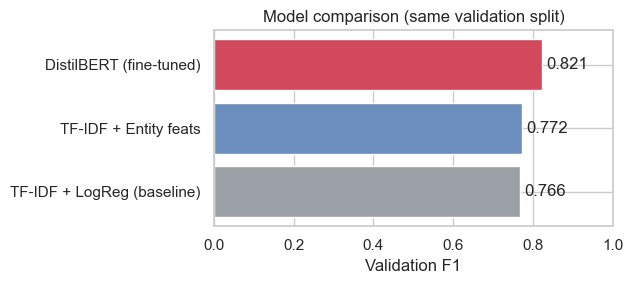

                     model  val_F1
TF-IDF + LogReg (baseline)  0.7661
     TF-IDF + Entity feats  0.7720
   DistilBERT (fine-tuned)  0.8213


In [20]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

f1_base = f1_score(y_va, pred_base_val)
f1_ent_ = f1_score(y_va, pred_ent_val)
f1_bert = f1_score(y_va, pred_bert_val)

summary = pd.DataFrame({
 "model": ["TF-IDF + LogReg (baseline)", "TF-IDF + Entity feats", "DistilBERT (fine-tuned)"],
 "val_F1": [f1_base, f1_ent_, f1_bert],
}).sort_values("val_F1")

fig, ax = plt.subplots(figsize=(6.5, 3))
bars = ax.barh(summary["model"], summary["val_F1"], color=["#9AA0A6", "#6C8EBF", "#D1495B"])
ax.set_xlim(0, 1); ax.set_xlabel("Validation F1")
ax.set_title("Model comparison (same validation split)")
for b, v in zip(bars, summary["val_F1"]): ax.text(v+0.01, b.get_y()+b.get_height()/2, f"{v:.3f}", va="center")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/model_compare.png", dpi=120); plt.show()
print(summary.round(4).to_string(index=False))

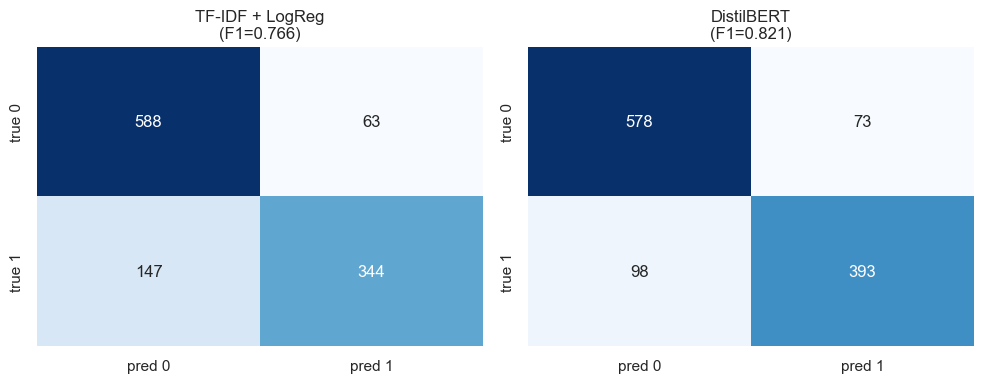

baseline   -> TN=588 FP=63 FN=147 TP=344
DistilBERT -> TN=578 FP=73 FN=98 TP=393


In [21]:
# 혼동행렬 baseline vs BERT 나란히
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pred, title in zip(axes, [pred_base_val, pred_bert_val],
 ["TF-IDF + LogReg", "DistilBERT"]):
 cm = confusion_matrix(y_va, pred)
 sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
 xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
 ax.set_title(f"{title}\n(F1={f1_score(y_va, pred):.3f})")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/confusion_matrix.png", dpi=120); plt.show()

# TN FP FN TP 풀어보기
for pred, name in [(pred_base_val, "baseline"), (pred_bert_val, "DistilBERT")]:
 tn, fp, fn, tp = confusion_matrix(y_va, pred).ravel()
 print(f"{name:10s} -> TN={tn} FP={fp} FN={fn} TP={tp}")

In [22]:
# precision/recall도 봐야 F1 정체 앎
print("=== DistilBERT classification report (val) ===")
print(classification_report(y_va, pred_bert_val, target_names=["not disaster(0)", "disaster(1)"], digits=4))

=== DistilBERT classification report (val) ===
                 precision    recall  f1-score   support

not disaster(0)     0.8550    0.8879    0.8711       651
    disaster(1)     0.8433    0.8004    0.8213       491

       accuracy                         0.8503      1142
      macro avg     0.8492    0.8441    0.8462      1142
   weighted avg     0.8500    0.8503    0.8497      1142



In [23]:
# 틀린 거 직접 읽어보기 (FP/FN)
val_df = train.loc[va_idx, ["text", "keyword", "target"]].copy()
val_df["pred"] = pred_bert_val

FP = val_df[(val_df.target == 0) & (val_df.pred == 1)] # 비재난->재난 오판
FN = val_df[(val_df.target == 1) & (val_df.pred == 0)] # 재난인데 놓침

print(f"False Positive {len(FP)}건 중 일부 (실제 0인데 1로 예측):\n")
for _, r in FP.head(6).iterrows():
 print(f" [kw={r.keyword}] {r.text}")
print(f"\n{'-'*80}\nFalse Negative {len(FN)}건 중 일부 (실제 1인데 0으로 예측):\n")
for _, r in FN.head(6).iterrows():
 print(f" [kw={r.keyword}] {r.text}")

False Positive 73건 중 일부 (실제 0인데 1로 예측):

  [kw=hellfire] #Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect
  [kw=floods] I hope it rains throughout the whole weekend I hope it floods and the portaloos become sentient.
  [kw=evacuate] Perhaps the criminal murderous #nazis should pack their bags &amp; evacuate themselves from London &amp; all #UK? #TubeStrike WELL DONE!
  [kw=thunder] The worst part is seeing lightning and trying to guess when the thunder will crack
  [kw=seismic] ENGLAND EAST COAST. Dogger Bank Westward. 1. Seismic survey in progress by M/V Western Regent towing a 8400 metre long cable within areaÛ_
  [kw=fatalities] The X-rays in MKX be looking like fatalities.

--------------------------------------------------------------------------------
False Negative 98건 중 일부 (실제 1인데 0으로 예측):

  [kw=fatalities] PolicyLab is at @CECANF's last public hearing in NYC today and tomorrow to addres

### FP / FN 분석

- FP: 재난 단어를 비유로 쓴 경우. on fire 같은
- FN: 재난인데 재난 단어가 없거나 라벨이 잘못된 경우
- 개선: threshold 조정, keyword를 입력에 결합, 더 큰 모델

## 4. 제출 파일 생성

In [24]:
# test 예측. 학습이랑 똑같은 전처리 써야 함
enc_te = encode(test["text"].map(light_clean))
test_ds = TensorDataset(enc_te["input_ids"], enc_te["attention_mask"])
test_loader = DataLoader(test_ds, batch_size=64)

test_pred = predict_logits(model, test_loader).argmax(1).numpy()

submission = pd.DataFrame({"id": test["id"], "target": test_pred})
submission.to_csv("submission.csv", index=False)
print("submission.csv 저장 완료:", submission.shape)
print("예측 분포:\n", submission["target"].value_counts())
print("\n", submission.head())
# 양성비율 train(0.43)이랑 비슷하면 ok

submission.csv 저장 완료: (3263, 2)
예측 분포:
 target
0    1991
1    1272
Name: count, dtype: int64

    id  target
0   0       1
1   2       1
2   3       1
3   9       1
4  11       1


## 마무리

| 단계 | 모델 | Validation F1 |
|---|---|---|
| Baseline | TF-IDF + LogReg | 0.766 |
| 추가 실험 | TF-IDF + 엔티티 피처 | 0.772 |
| 개선 | DistilBERT | 0.821 |

- BoW만으로도 0.76. 엔티티 피처는 효과 작음. 개선은 DistilBERT
- 한계: 비유 표현, 라벨 오류